<a href="https://colab.research.google.com/github/sflmnt/Business-Intelligence/blob/main/Reto6_Sof%C3%ADaLomanto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0. Instalación de las Librerias

In [35]:
!pip install tensorflow #Libreria nativa para el diseño de redes neuronales

1. Se procede con la cara de las librerias de trabajo

In [36]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2. Se procede con la cara de los datos de trabajo

In [37]:
nxl= '/content/drive/MyDrive/Análitica 2025-1/6. SolicitantesCrédito(USD) (2).xlsx'
XDB= pd.read_excel(nxl, sheet_name=1) #Base de datos Triple A
XDB=XDB[['Edad','Hijos','Perscargo','Estrato','Ingresos','Egresos','Monto (EAD)','Plazo','Cuota (COP)','Score']]
display(XDB)

#Separamos las variables por entrada y salida
XD=np.array(XDB[['Edad','Hijos','Perscargo','Estrato','Ingresos','Egresos','Monto (EAD)','Plazo','Cuota (COP)']])
yd=np.array(XDB[['Score']])

#Se procede con la normalización de las variables
XDn=XD/np.max(XD,axis=0)  #axis=0 que lo haga por columnas
ydn=yd/np.max(yd,axis=0)

print("Los datos de etrada son:\n",XDn)

,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP),Score
0,38,1,0,3,1356.14400,1685.622667,625.562230,48,18.375890,582.478943
1,51,6,1,4,286.01600,364.462000,140.031984,36,5.062492,479.839966
2,37,2,0,3,517.46325,629.208889,284.564492,36,10.287688,417.653107
3,29,1,0,2,473.27000,551.616889,309.647588,24,15.458878,316.791107
4,42,3,4,2,750.09175,806.715778,500.663578,24,24.995180,441.809570
...,...,...,...,...,...,...,...,...,...,...
5837,48,0,0,3,1207.84800,753.801111,748.041791,36,27.043503,550.980408
5838,31,2,0,5,1472.77200,953.812889,870.793819,48,25.579568,659.471375
5839,38,0,0,3,773.01975,672.910667,594.947894,36,21.508792,465.011536
5840,43,1,2,2,635.50175,780.691556,305.580539,36,11.047468,423.237305


Los datos de etrada son:
 [[0.52054795 0.14285714 0.         ... 0.15349289 0.8        0.02045638]
 [0.69863014 0.85714286 0.2        ... 0.03435935 0.6        0.00563566]
 [0.50684932 0.28571429 0.         ... 0.06982299 0.6        0.01145244]
 ...
 [0.52054795 0.         0.         ... 0.14598111 0.6        0.02394398]
 [0.5890411  0.14285714 0.4        ... 0.07497965 0.6        0.01229825]
 [0.50684932 0.14285714 0.4        ... 0.246751   0.6        0.04047237]]


3. Se implementa el modelo neuronal

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1219
Epoch 2/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0466
Epoch 3/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0331
Epoch 4/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0282
Epoch 5/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0229
Epoch 6/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0176
Epoch 7/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0143
Epoch 8/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0110
Epoch 9/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0094
Epoch 10/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0077
Epoch 11/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0060
Epoch 12/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0049
Epoch 13/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0041
Epoch 14/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0035
Epoch 15/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0

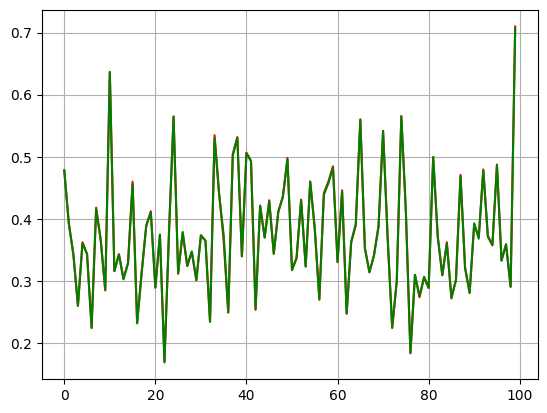

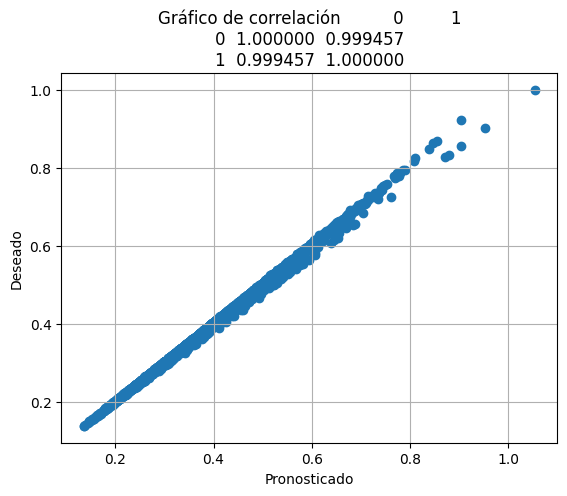

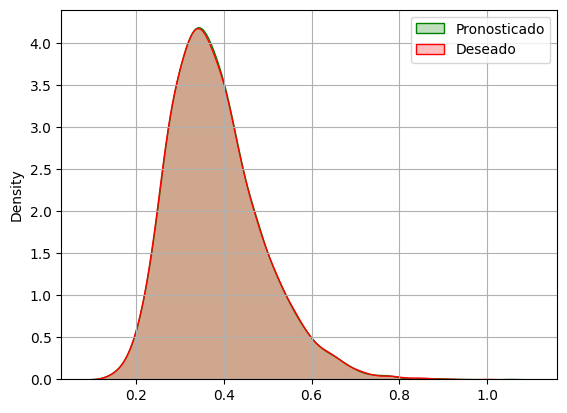

In [39]:
#Adaptive Linear (Relu - Regresión Lineal)
np.random.seed(42)
adaline=tf.keras.models.Sequential([tf.keras.layers.Dense(units=1,input_shape=(9,),
                                                          use_bias=False, activation='relu')])

adaline.compile(optimizer='sgd',loss='mse')   #mse:Error entre ydn y lo que tenga la red
                                              #sdg: Método gradiente para reducir el error
adaline.summary()
history=adaline.fit(XDn,ydn,epochs=100)     #epochs: Número de veces que recorre la Tabla

#Evaluamos el comportamiento del modelo
yp=adaline.predict(XDn)
print("Los datos de salida son:\n",yd)
dfcorr=pd.DataFrame(np.column_stack((yp,ydn))) #comparar comportamiento del modelo
print("La correlación entre yp-ydn es :\n", dfcorr.corr())

#obtenemos las conexiones nerviosas
w=adaline.get_weights()
print("Los pesos de la red neuronal son:\n",w)

#Gráficamos los resultados
plt.figure()
plt.plot(ydn[0:100,],'r',label= 'Deseado')
plt.plot(yp[0:100,],'g',label= 'Pronosticado')
plt.grid(True)
plt.show()

#Gráfico de Correlación
#Debe haber una predominancia de la diagonal principal
plt.figure()
plt.scatter(yp,ydn)
plt.grid(True)
plt.xlabel('Pronosticado')
plt.ylabel('Deseado')
plt.title('Gráfico de correlación'+ str (dfcorr.corr()))
plt.show()

#Gráfico de Distribuciones
plt.figure()
sns.kdeplot(x=yp.flatten(),label='Pronosticado',fill=True , color= 'g')
sns.kdeplot(x=ydn.flatten(),label='Deseado',fill=True , color= 'r')
plt.grid(True)
plt.legend()
plt.show()



4. Se evalúa una persona de forma única

In [19]:
Xnp=[[45,1,0,4,2000,1000,1200,24,60]]
Xnpn=Xnp/np.max(XD,axis=0)  #Normalizar los datos de entrada
print("Los datos de entrada son:\n",Xnpn)
ypnp=adaline.predict(Xnpn)
print("El score estimado es:\n",ypnp*np.max(yd)) #Salida Desnormalizar Máximo

Los datos de entrada son:
 [[0.61643836 0.14285714 0.         0.66666667 0.66780533 0.31829503
  0.29444147 0.4        0.0667931 ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
El score estimado es:
 [[595.71295624]]


5. Se crea el modelo MADALINE (Multi Adaptive Linear - Relu) Este modelo puede integrar cualquier número de regresiones en una sola estructura

In [40]:
nxl= '/content/drive/MyDrive/Análitica 2025-1/6. SolicitantesCrédito(USD) (2).xlsx'
XDB= pd.read_excel(nxl, sheet_name=1) #Base de datos Triple A
XDB=XDB[['Edad','Hijos','Perscargo','Estrato','Ingresos','Egresos','Monto (EAD)','Plazo','Cuota (COP)','Score']]
display(XDB)

#Separamos las variables por entrada y salida
XD=np.array(XDB[['Edad','Hijos','Perscargo','Estrato','Ingresos','Egresos','Monto (EAD)','Plazo','Cuota (COP)']])
yd=np.array(XDB[['Score']])

#Se procede con la normalización de las variables
XDn=XD/np.max(XD,axis=0)  #axis=0 que lo haga por columnas
ydn=yd/np.max(yd,axis=0)

print("Los datos de entrada son:\n",XDn)

,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP),Score
0,38,1,0,3,1356.14400,1685.622667,625.562230,48,18.375890,582.478943
1,51,6,1,4,286.01600,364.462000,140.031984,36,5.062492,479.839966
2,37,2,0,3,517.46325,629.208889,284.564492,36,10.287688,417.653107
3,29,1,0,2,473.27000,551.616889,309.647588,24,15.458878,316.791107
4,42,3,4,2,750.09175,806.715778,500.663578,24,24.995180,441.809570
...,...,...,...,...,...,...,...,...,...,...
5837,48,0,0,3,1207.84800,753.801111,748.041791,36,27.043503,550.980408
5838,31,2,0,5,1472.77200,953.812889,870.793819,48,25.579568,659.471375
5839,38,0,0,3,773.01975,672.910667,594.947894,36,21.508792,465.011536
5840,43,1,2,2,635.50175,780.691556,305.580539,36,11.047468,423.237305


Los datos de entrada son:
 [[0.52054795 0.14285714 0.         ... 0.15349289 0.8        0.02045638]
 [0.69863014 0.85714286 0.2        ... 0.03435935 0.6        0.00563566]
 [0.50684932 0.28571429 0.         ... 0.06982299 0.6        0.01145244]
 ...
 [0.52054795 0.         0.         ... 0.14598111 0.6        0.02394398]
 [0.5890411  0.14285714 0.4        ... 0.07497965 0.6        0.01229825]
 [0.50684932 0.14285714 0.4        ... 0.246751   0.6        0.04047237]]


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 10)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100 (400.00 B)

 Trainable params: 100 (400.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0062
Epoch 2/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0052
Epoch 3/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0041
Epoch 4/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0033
Epoch 5/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0028
Epoch 6/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0023
Epoch 7/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0020
Epoch 8/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0017
Epoch 9/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0015
Epoch 10/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0014
Epoch 11/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0013
Epoch 12/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0011
Epoch 13/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0011
Epoch 14/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9.7918e-04
Epoch 15/100
183/183 ━━━━━━━━━━━━━━━━━━

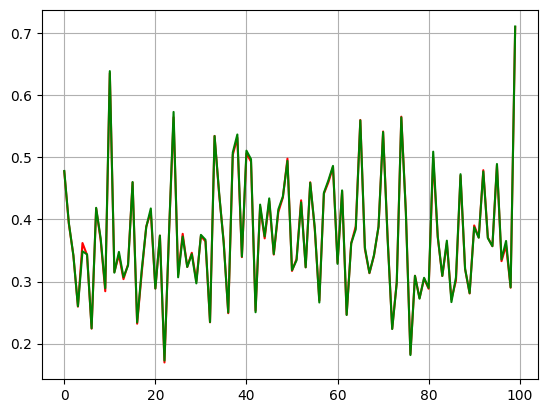

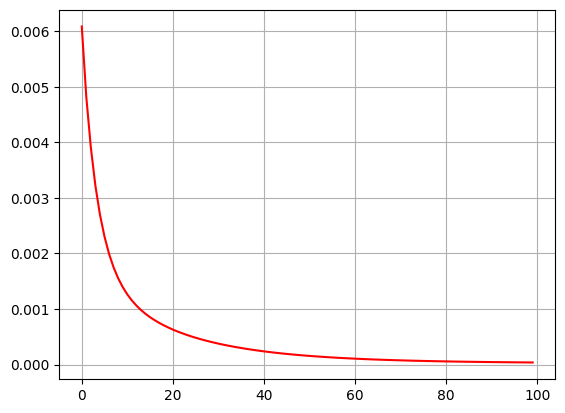

Los efectos independientes son:
 [[ 0.00783548]
 [-0.13006693]
 [ 0.05349518]
 [ 0.24607408]
 [ 0.17412052]
 [-0.06562975]
 [ 0.25132456]
 [ 0.2607695 ]
 [ 0.10251604]]


,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
0,0.007835,-0.130067,0.053495,0.246074,0.174121,-0.06563,0.251325,0.260769,0.102516


In [41]:
madaline=tf.keras.models.Sequential([
    tf.keras.layers.Dense(units=10,input_shape=(9,),use_bias=False, activation='relu'),
    tf.keras.layers.Dense(units=1,use_bias=False,activation='relu')])

madaline.summary()

madaline.load_weights('/content/drive/MyDrive/Análitica 2025-1/pesos_madaline_M.weights.h5')
madaline.compile(optimizer='sgd',loss='mse')
history2=madaline.fit(XDn,ydn,epochs=100)

#Evaluamos el modelo
yp2=madaline.predict(XDn)
dfcorr2=pd.DataFrame(np.column_stack((yp2,ydn)))
print("La correlación entre yp-ydn es :\n", dfcorr2.corr())

#Caida del error en el aprendizaje
ek=history2.history['loss'] #Muestra el error en el aprendizaje


plt.figure()
plt.plot(ydn[0:100,],'r',label= 'Deseado')
plt.plot(yp2[0:100,],'g',label= 'Pronosticado')
plt.grid(True)
plt.show()

plt.figure()
plt.plot(ek,'r')
plt.grid(True)
plt.show()

#Se procede con el análisis de efectos independientes
W=np.array(madaline.layers[0].get_weights()) [0]
C=np.array(madaline.layers[1].get_weights()) [0]
a=W@C
print("Los efectos independientes son:\n",a)
dfm=pd.DataFrame(a.T)
dfm.columns=['Edad','Hijos','Perscargo','Estrato','Ingresos','Egresos','Monto (EAD)','Plazo','Cuota (COP)']
display(dfm)


6. Evaluamos la persona

In [10]:
Xnp=[[45,1,0,4,2000,1000,1200,24,60]]
Xnpn=Xnp/np.max(XD,axis=0)  #Normalizar los datos de entrada
print("Los datos de entrada son:\n",Xnpn)
ypnp=madaline.predict(Xnpn)
print("El score estimado es:\n",ypnp*np.max(yd)) #Salida Desnormalizar Máximo

Los datos de entrada son:
 [[0.61643836 0.14285714 0.         0.66666667 0.66780533 0.31829503
  0.29444147 0.4        0.0667931 ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
El score estimado es:
 [[677.67258172]]


7. **Modelos Sigmoidales=** Explican porcentajes o probabilidades

In [42]:
nxl= '/content/drive/MyDrive/Análitica 2025-1/6. SolicitantesCrédito(USD) (2).xlsx'
XDB= pd.read_excel(nxl, sheet_name=1) #Base de datos Triple A
XDB=XDB[['Edad','Hijos','Perscargo','Estrato','Ingresos','Egresos','Monto (EAD)','Plazo','Cuota (COP)','Prob.Default (PD)']]
display(XDB)

#Separamos las variables por entrada y salida
XD=np.array(XDB[['Edad','Hijos','Perscargo','Estrato','Ingresos','Egresos','Monto (EAD)','Plazo','Cuota (COP)']])
yd=np.array(XDB[['Prob.Default (PD)']])

#Se procede con la normalización de las variables
XDn=XD/np.max(XD,axis=0)  #axis=0 que lo haga por columnas
ydn=yd/np.max(yd,axis=0)
print("Los datos de entrada son:\n",XDn)

,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP),Prob.Default (PD)
0,38,1,0,3,1356.14400,1685.622667,625.562230,48,18.375890,0.041659
1,51,6,1,4,286.01600,364.462000,140.031984,36,5.062492,0.234951
2,37,2,0,3,517.46325,629.208889,284.564492,36,10.287688,0.170330
3,29,1,0,2,473.27000,551.616889,309.647588,24,15.458878,0.201659
4,42,3,4,2,750.09175,806.715778,500.663578,24,24.995180,0.140929
...,...,...,...,...,...,...,...,...,...,...
5837,48,0,0,3,1207.84800,753.801111,748.041791,36,27.043503,0.056132
5838,31,2,0,5,1472.77200,953.812889,870.793819,48,25.579568,0.035120
5839,38,0,0,3,773.01975,672.910667,594.947894,36,21.508792,0.101976
5840,43,1,2,2,635.50175,780.691556,305.580539,36,11.047468,0.156707


Los datos de entrada son:
 [[0.52054795 0.14285714 0.         ... 0.15349289 0.8        0.02045638]
 [0.69863014 0.85714286 0.2        ... 0.03435935 0.6        0.00563566]
 [0.50684932 0.28571429 0.         ... 0.06982299 0.6        0.01145244]
 ...
 [0.52054795 0.         0.         ... 0.14598111 0.6        0.02394398]
 [0.5890411  0.14285714 0.4        ... 0.07497965 0.6        0.01229825]
 [0.50684932 0.14285714 0.4        ... 0.246751   0.6        0.04047237]]


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 10)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100 (400.00 B)

 Trainable params: 100 (400.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0343
Epoch 2/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0336
Epoch 3/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0322
Epoch 4/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0303
Epoch 5/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0291
Epoch 6/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0293
Epoch 7/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0274
Epoch 8/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0260
Epoch 9/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0256
Epoch 10/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0246
Epoch 11/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0237
Epoch 12/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0224
Epoch 13/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0227
Epoch 14/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0217
Epoch 15/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1

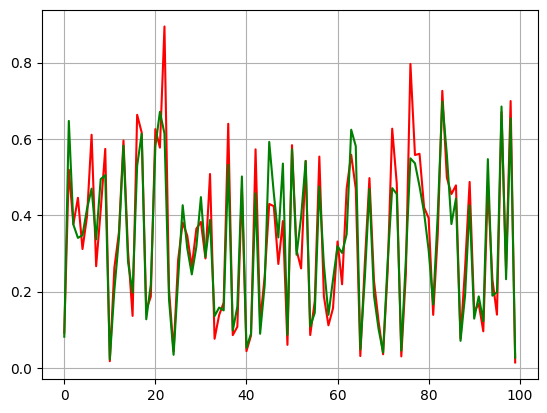

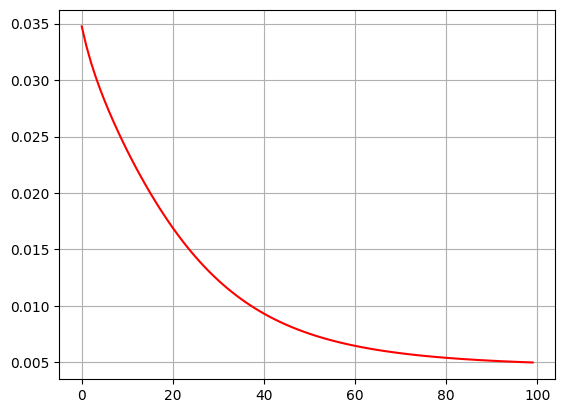

Los efectos independientes son:
 [[ 0.51188385]
 [ 0.51762545]
 [-0.01531538]
 [-0.13327417]
 [-4.193176  ]
 [-2.1192813 ]
 [-1.8069923 ]
 [-0.19603845]
 [-1.4477646 ]]
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
La correlación entre yp2-ydn es :
           0         1
0  1.000000  0.951906
1  0.951906  1.000000


In [43]:
madaline=tf.keras.models.Sequential([
    tf.keras.layers.Dense(units=10,input_shape=(9,),use_bias=False, activation='relu'),
    tf.keras.layers.Dense(units=1,use_bias=False,activation='sigmoid')])

madaline.load_weights('/content/drive/MyDrive/Análitica 2025-1/pesos_sigmoid_M.weights.h5')
madaline.summary()
madaline.compile(optimizer='sgd',loss='mse')
history2=madaline.fit(XDn,ydn,epochs=100)

#Evaluamos el modelo
yp2=madaline.predict(XDn)
dfcorr2=pd.DataFrame(np.column_stack((yp2,ydn)))
print("La correlación entre yp-ydn es :\n", dfcorr2.corr())

#Caida del error en el aprendizaje
ek=history2.history['loss'] #Muestra el error en el aprendizaje


plt.figure()
plt.plot(ydn[0:100,],'r',label= 'Deseado')
plt.plot(yp2[0:100,],'g',label= 'Pronosticado')
plt.grid(True)
plt.show()

plt.figure()
plt.plot(ek,'r')
plt.grid(True)
plt.show()

#Se procede con el análisis de efectos independientes
WC=madaline.get_weights()
W=WC[0]; C=WC[1]
a=W@C
print("Los efectos independientes son:\n",a)
yp2=madaline.predict(XDn)
dfcorr2=pd.DataFrame(np.column_stack((yp2,ydn)))
print("La correlación entre yp2-ydn es :\n", dfcorr2.corr())


8. Para evaluar a una persona

In [44]:
Xnp=[[45,1,0,4,2000,1000,1200,24,60]]
Xnpn=Xnp/np.max(XD,axis=0)  #Normalizar los datos de entrada
print("Los datos de entrada son:\n",Xnpn)
ypnp2=madaline.predict(Xnpn)
print("El score estimado es:\n",ypnp2*np.max(yd)) #Salida Desnormalizar Máximo

Los datos de entrada son:
 [[0.61643836 0.14285714 0.         0.66666667 0.66780533 0.31829503
  0.29444147 0.4        0.0667931 ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
El score estimado es:
 [[0.02252757]]


# **Análisis de resultados:**

A partir de los resultados del modelo, se puede concluir que ambos modelos utilizados (Sigmoidal para la estimación de la Probabilidad de Default y MADALINE para el Score de Crédito) presentaron un desempeño excelente. El modelo Sigmoidal obtuvo un coeficiente de correlación de más de 95%, indicando una fuerte relación entre las variables y la probabilidad de incumplimiento. Por su parte, el modelo MADALINE alcanzó una correlación aún más alta, de más del 99% reflejando una precisión casi perfecta en la predicción del score.

En cuanto a las variables más influyentes, el modelo Sigmoidal mostró que tener hijos incrementa significativamente la probabilidad de default, mientras que ingresos fue la variable con el mayor efecto negativo, es decir, reduce el riesgo. Le sigue egresos como segundo factor con efecto negativo.

Para el modelo MADALINE, la variable con mayor efecto positivo en el score fue el plazo, y la de menor impacto fue la edad. La variable con mayor efecto negativo fue egresos, lo que concuerda con un menor margen financiero.

Para un solicitante con las características (Edad (45), Hijos (1), Personas a Cargo (0), Estrato (4), Ingresos (2000), Egresos (1000), Monto (1200), Plazo (24), Cuota (60).) , el modelo estimó una probabilidad de default de 22% aproximadamente (riesgo bajo) y un score de crédito de 677 aproximadamente, considerado aceptable.

En resumen, los modelos son altamente efectivos y permiten identificar claramente los factores socioeconómicos que inciden en el riesgo crediticio, facilitando decisiones más informadas al otorgar créditos.

